In [1]:
import pandas as pd
import os
import pandas as pd

# Directory containing the folders
base_dir = 'allele_differences_withoutcontrol/20240813_allele_only'
# Initialize an empty DataFrame for the final result
final_df = pd.DataFrame()

# Loop through each folder in the base directory
for file in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file)

        df_ref = pd.read_csv(file_path,index_col=0)[["logFC"]]
        df_ref.columns = [file[21:-15]]

        # Append to the final DataFrame
        final_df = pd.concat([final_df, df_ref],axis=1)

#final_df=final_df.rename({"THP1Monocyte":"THP1 Monocyte","THP1Macrophage":"THP1 Macrophage","BrainR1R2merged20240404":"Brain","HMC3":"HMC3 Microglia", "GutR1R2merged20240404": "Gut"},axis=1)
final_df=final_df.rename({"THP1Monocyte":"THP1 Monocyte","THP1Macrophage":"THP1 Macrophage","BrainR1R2merged20240404":"Brain","HMC3":"HMC3 Microglia", "GutR1R2merged20240404": "Gut","GutR1R2merged20240404_LI": "Large_Intestine",
                          "GutR1R2merged20240404_SI": "Small_Intestine","BrainR1R2merged20240404_Cortex":"Brain_Cortex","BrainR1R2merged20240404_Hippocampus":"Brain_Hippocampus","BrainR1R2merged20240404_Striatum":"Brain_Striatum"},axis=1)

In [12]:
df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_202401021.csv',index_col=0)
final_df = pd.merge(final_df,df_index[['rsid_gene']],left_index=True,right_index=True)

Index(['HMC3_IFNB', 'Gut', 'HMC3 Microglia', 'THP1 Monocyte', 'HEK293T',
       'THP1 Macrophage', 'Large_Intestine', 'HMC3_IFNG', 'THP1_IFNB',
       'Small_Intestine', 'THP1_IFNG', 'HMC3THP1mac_CommonEffects', 'Brain',
       'Brain_Cortex', 'Brain_Hippocampus', 'Brain_Striatum', 'HMC3_LPSIFNG',
       'HMC3_Naive', 'THP1_LPSIFNG', 'THP1_Naive', 'rsid_gene'],
      dtype='object')


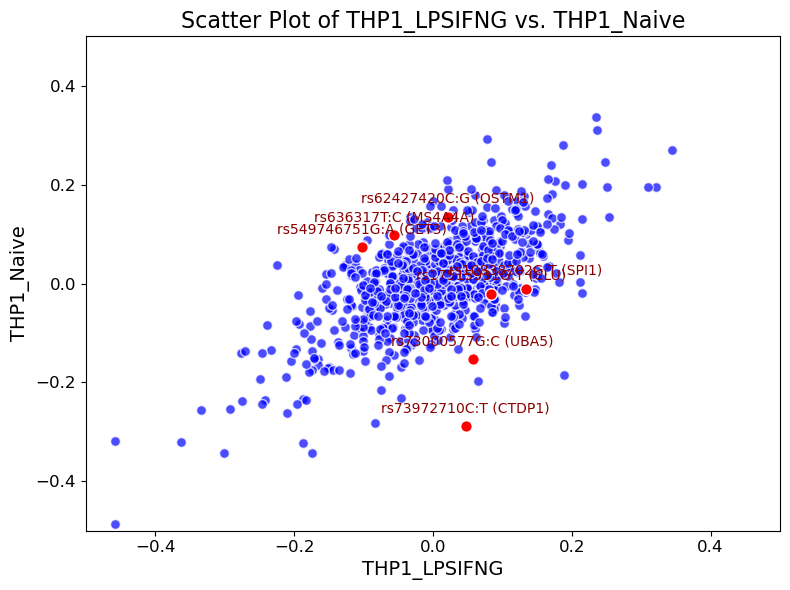

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the data for outliers
df_outlier = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only_interaction/20240812_comparative_THP1_LPSIFNGvsNaive_interaction.csv', index_col=0)
outlier_index = df_outlier[df_outlier['fdr'] <= 0.1].index

# Assuming 'final_df' is already loaded and contains the appropriate columns
print(final_df.columns)  # Just to confirm the columns

# Select the data
x = final_df['THP1_LPSIFNG']
y = final_df['THP1_Naive']

# Create scatter plot
plt.figure(figsize=(8, 6))

# Plot all points in blue initially
plt.scatter(x, y, alpha=0.7, edgecolors='w', s=50, color='blue')

# Highlight outliers in red
for idx in outlier_index:
    if idx in final_df.index:  # Check if the outlier index is in final_df
        plt.scatter(x[idx], y[idx], color='red', edgecolors='w', s=70)  # Larger, red marker for outliers
        label = final_df.loc[idx, 'rsid_gene']
        plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center', color='darkred')

# Enhancing the plot
plt.title('Scatter Plot of THP1_LPSIFNG vs. THP1_Naive', fontsize=16)
plt.xlabel('THP1_LPSIFNG', fontsize=14)
plt.ylabel('THP1_Naive', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.tight_layout()
plt.show()


Regression line: y = 0.61x + -0.00


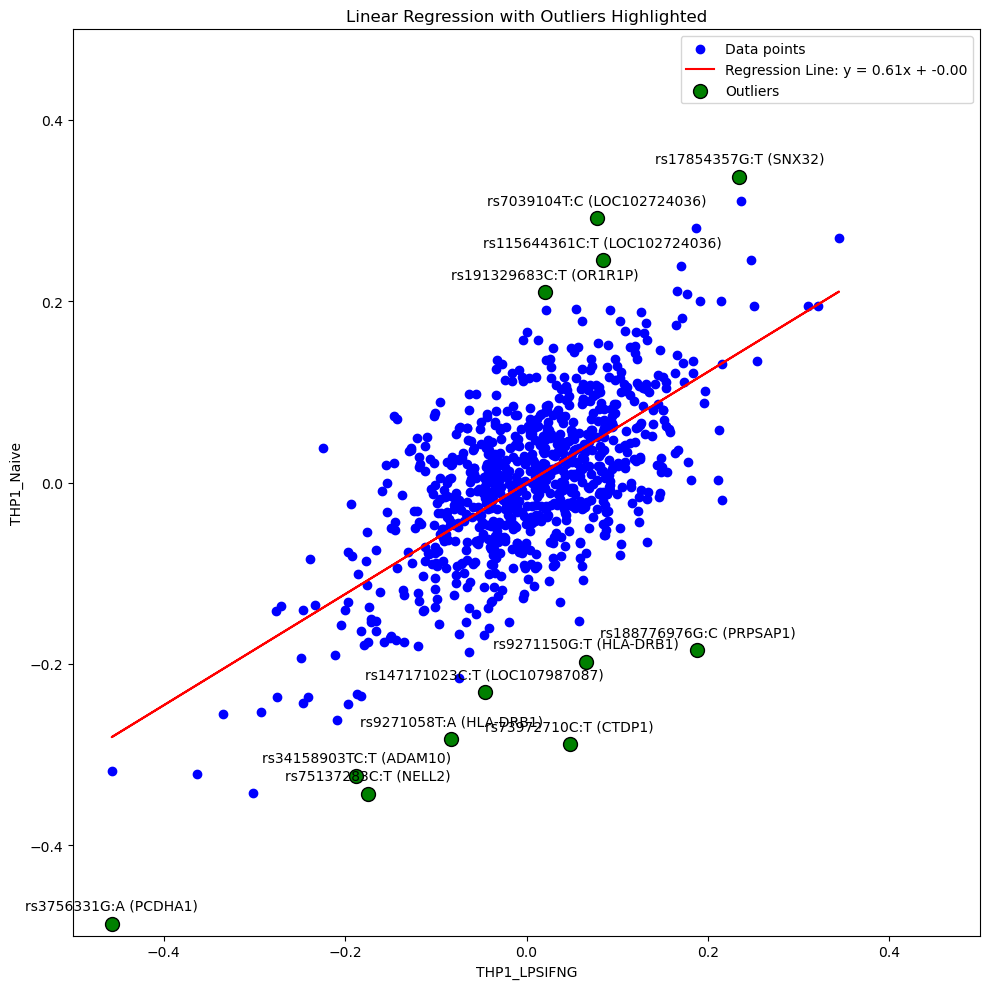

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df['THP1_LPSIFNG']
y = final_df['THP1_Naive']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel('THP1_LPSIFNG')
plt.ylabel('THP1_Naive')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.legend()
plt.tight_layout()
plt.show()


Regression line: y = 0.81x + 0.00


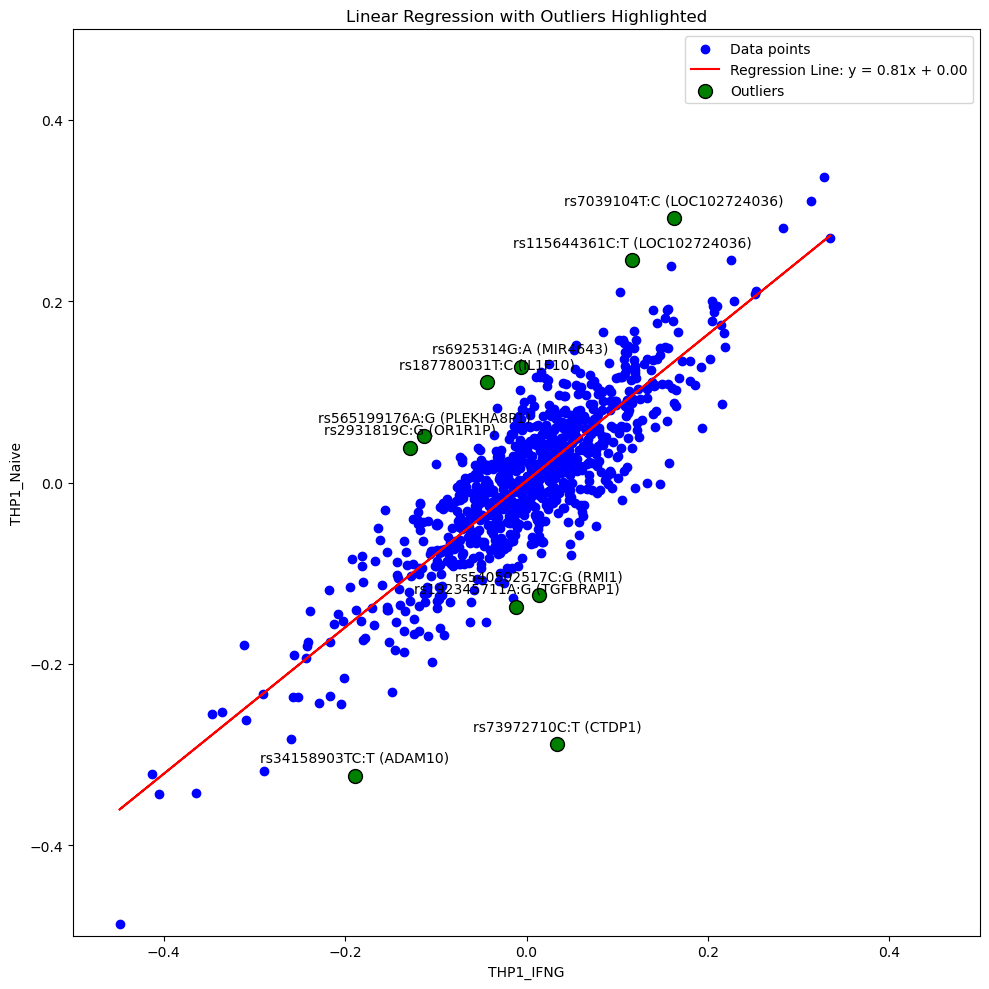

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df['THP1_IFNG']
y = final_df['THP1_Naive']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel('THP1_IFNG')
plt.ylabel('THP1_Naive')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.legend()
plt.tight_layout()
plt.show()


Regression line: y = 0.81x + 0.00


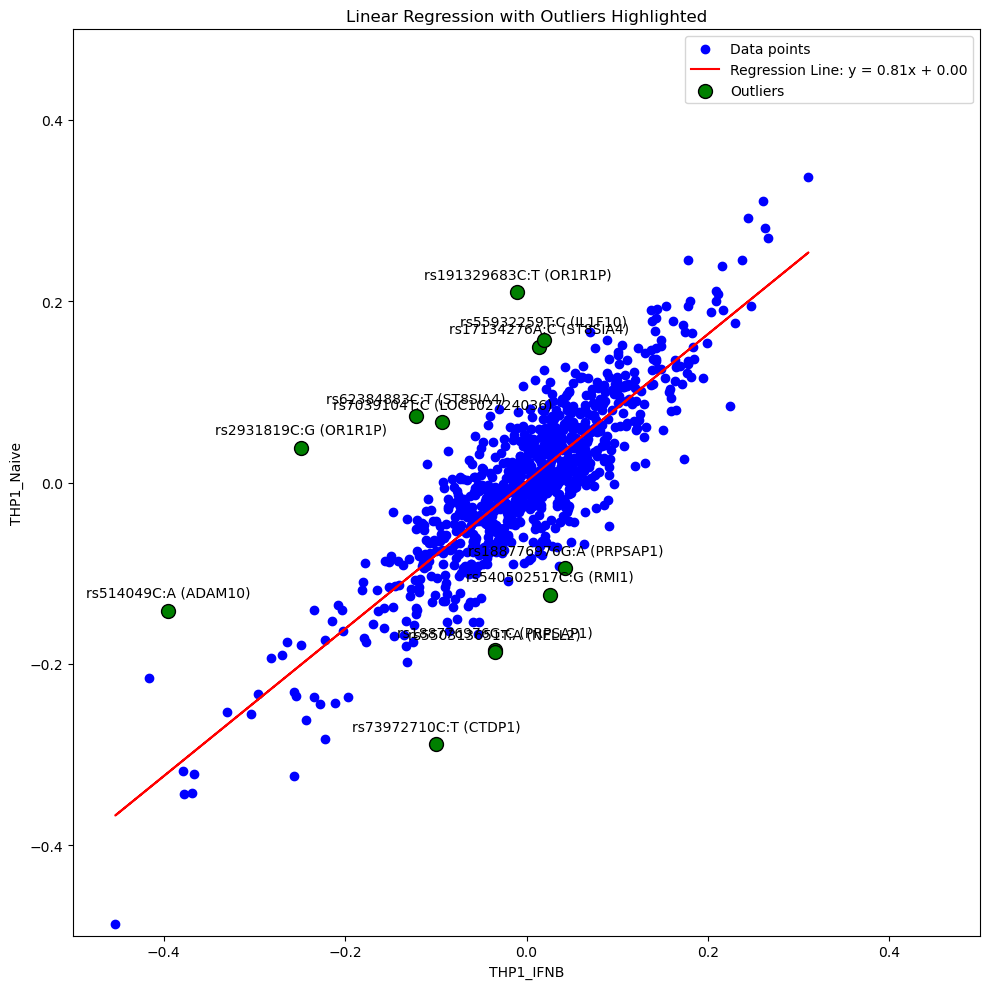

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df['THP1_IFNB']
y = final_df['THP1_Naive']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel('THP1_IFNB')
plt.ylabel('THP1_Naive')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.legend()
plt.tight_layout()
plt.show()


Regression line: y = 0.48x + 0.00


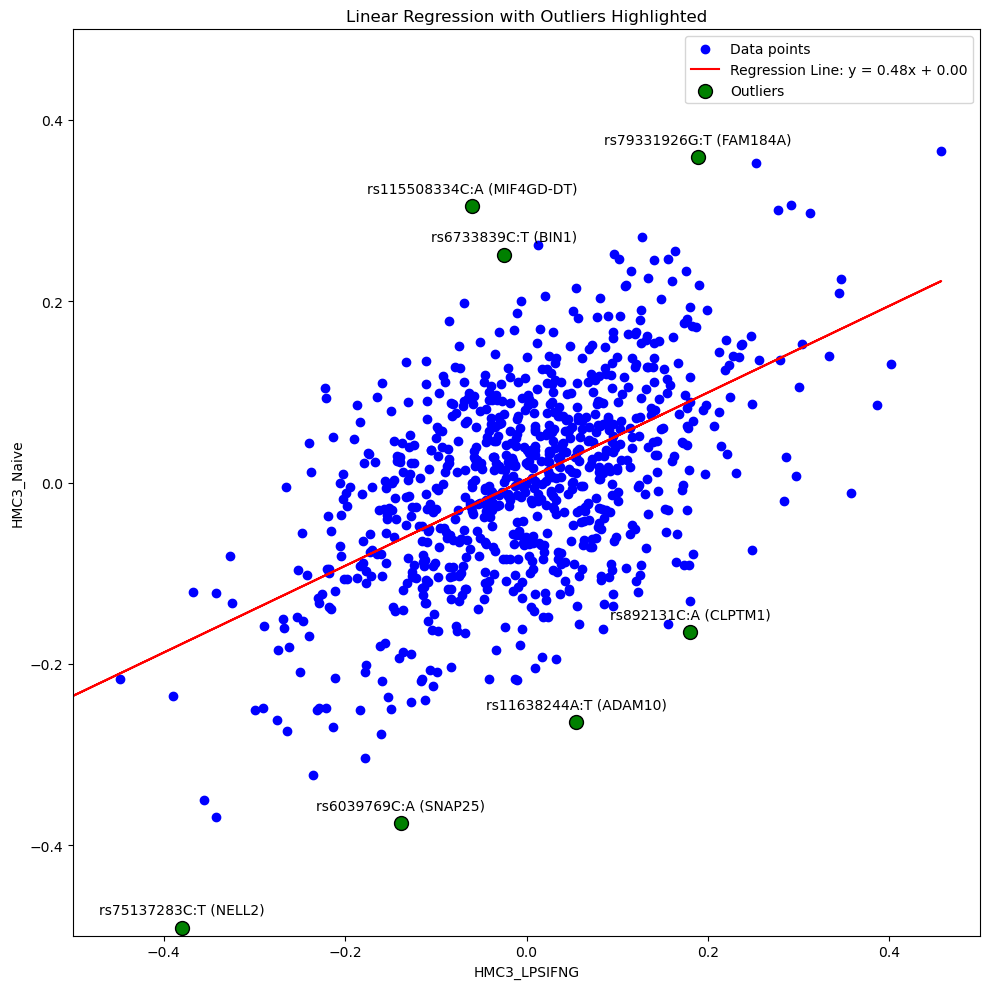

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df['HMC3_LPSIFNG']
y = final_df['HMC3_Naive']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel('HMC3_LPSIFNG')
plt.ylabel('HMC3_Naive')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
final_df

,HMC3_IFNB,Gut,HMC3 Microglia,THP1 Monocyte,HEK293T,THP1 Macrophage,Large_Intestine,HMC3_IFNG,THP1_IFNB,Small_Intestine,...,HMC3THP1mac_CommonEffects,Brain,Brain_Cortex,Brain_Hippocampus,Brain_Striatum,HMC3_LPSIFNG,HMC3_Naive,THP1_LPSIFNG,THP1_Naive,rsid_gene
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.071932,0.109339,0.064421,-0.002860,0.007046,0.037138,0.177346,-0.028760,-0.000276,0.064337,...,0.048500,0.389910,0.302908,0.397342,0.465512,0.149918,0.059736,0.036042,0.047657,cg03073402C:G (LIPE)
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,-0.256338,-0.362689,-0.184548,0.021697,-0.223414,-0.132102,-0.315206,-0.165707,-0.118848,-0.443498,...,-0.155331,-0.350345,-0.271034,-0.391682,-0.426874,-0.252059,-0.096984,-0.161738,-0.121268,cg03169557C:G (SPG7)
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,0.083336,-0.154440,-0.052038,-0.252467,-0.084894,-0.086250,-0.257660,-0.062388,-0.088985,-0.058082,...,-0.069752,0.085144,0.229938,-0.031806,0.074287,-0.071528,-0.123967,-0.116701,-0.045987,cg05030077C:G (MLST8)
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,0.023314,-0.083965,-0.014730,-0.027485,-0.135820,-0.069255,0.135280,-0.112537,-0.057084,-0.233364,...,-0.052519,-0.193548,-0.211632,-0.155912,-0.192127,-0.038846,0.071482,0.036451,-0.131616,cg05066959C:G (ANK1)
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,-0.129527,-0.057920,-0.029703,0.016020,-0.002832,0.100701,-0.174452,-0.021303,0.075087,0.071760,...,0.044256,-0.053136,0.166639,-0.176891,-0.155385,-0.109357,0.090490,0.028653,0.148702,cg05228284C:G (DIRAS1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,0.025124,-0.329345,-0.032493,0.124189,-0.010656,-0.027981,-0.402404,0.016424,-0.036765,-0.234712,...,-0.030030,-0.264328,-0.343922,-0.128992,-0.376754,-0.153599,-0.036107,-0.042009,-0.029592,rs9478143A:G (MTHFD1L)
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,-0.009635,-0.194385,0.026681,-0.152758,0.024478,0.057097,-0.142946,0.012723,0.015715,-0.258867,...,0.043629,-0.227773,-0.313936,-0.427504,0.042072,0.050214,0.061010,0.085821,0.050067,rs953471G:A (NEK6)
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,-0.042198,-0.323945,-0.017008,-0.079274,0.019461,-0.022522,-0.249593,-0.116513,-0.041770,-0.387486,...,-0.021492,-0.300100,-0.217406,-0.409192,-0.320158,-0.055244,0.061306,-0.005010,-0.008746,rs965034941CCA:C (BTBD2)
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0.045607,0.125249,0.021067,-0.056492,0.101050,0.028273,0.126356,0.118931,0.031456,0.077388,...,0.026483,0.153639,0.283104,0.026957,0.138477,0.038169,-0.078040,0.035175,0.034495,rs983392A:G (MS4A6A)


Regression line: y = 0.75x + 0.01


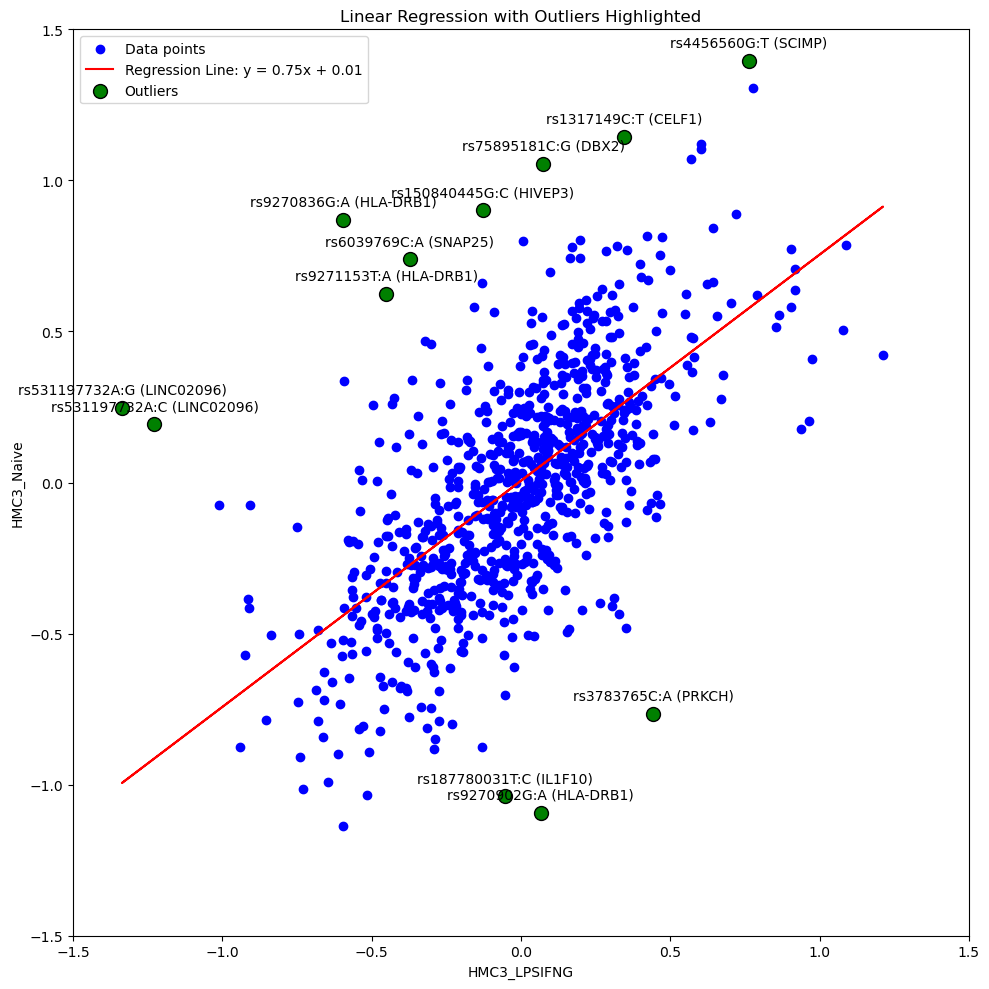

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df['Brain_Cortex']
y = final_df['Brain_Hippocampus']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel('HMC3_LPSIFNG')
plt.ylabel('HMC3_Naive')
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.legend()
plt.tight_layout()
plt.show()


Regression line: y = 0.75x + 0.01


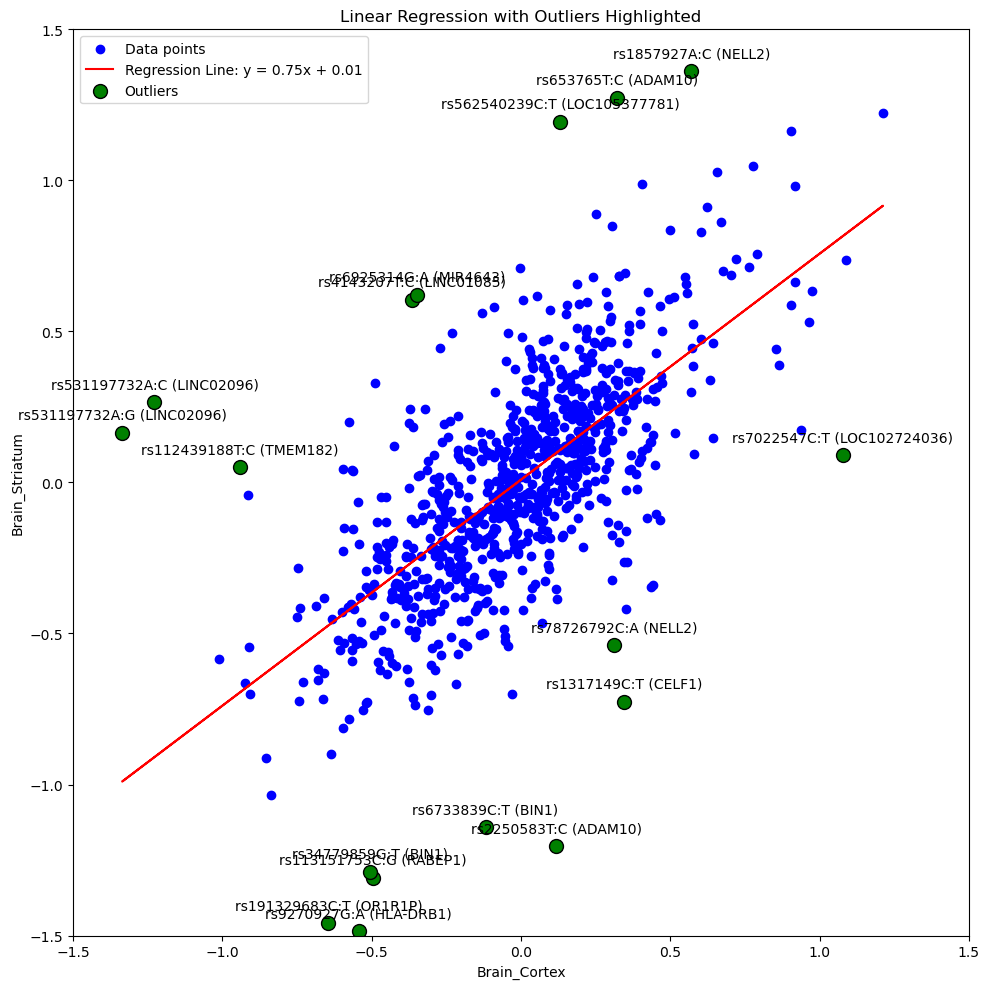

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
x_name = 'Brain_Cortex'
y_name = 'Brain_Striatum'
# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df[x_name]
y = final_df[y_name]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel(x_name)
plt.ylabel(y_name)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
final_df

,HMC3_IFNB,Gut,HMC3 Microglia,THP1 Monocyte,HEK293T,THP1 Macrophage,Large_Intestine,HMC3_IFNG,THP1_IFNB,Small_Intestine,...,HMC3THP1mac_CommonEffects,Brain,Brain_Cortex,Brain_Hippocampus,Brain_Striatum,HMC3_LPSIFNG,HMC3_Naive,THP1_LPSIFNG,THP1_Naive,rsid_gene
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.071932,0.109339,0.064421,-0.002860,0.007046,0.037138,0.177346,-0.028760,-0.000276,0.064337,...,0.048500,0.389910,0.302908,0.397342,0.465512,0.149918,0.059736,0.036042,0.047657,cg03073402C:G (LIPE)
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,-0.256338,-0.362689,-0.184548,0.021697,-0.223414,-0.132102,-0.315206,-0.165707,-0.118848,-0.443498,...,-0.155331,-0.350345,-0.271034,-0.391682,-0.426874,-0.252059,-0.096984,-0.161738,-0.121268,cg03169557C:G (SPG7)
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,0.083336,-0.154440,-0.052038,-0.252467,-0.084894,-0.086250,-0.257660,-0.062388,-0.088985,-0.058082,...,-0.069752,0.085144,0.229938,-0.031806,0.074287,-0.071528,-0.123967,-0.116701,-0.045987,cg05030077C:G (MLST8)
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,0.023314,-0.083965,-0.014730,-0.027485,-0.135820,-0.069255,0.135280,-0.112537,-0.057084,-0.233364,...,-0.052519,-0.193548,-0.211632,-0.155912,-0.192127,-0.038846,0.071482,0.036451,-0.131616,cg05066959C:G (ANK1)
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,-0.129527,-0.057920,-0.029703,0.016020,-0.002832,0.100701,-0.174452,-0.021303,0.075087,0.071760,...,0.044256,-0.053136,0.166639,-0.176891,-0.155385,-0.109357,0.090490,0.028653,0.148702,cg05228284C:G (DIRAS1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,0.025124,-0.329345,-0.032493,0.124189,-0.010656,-0.027981,-0.402404,0.016424,-0.036765,-0.234712,...,-0.030030,-0.264328,-0.343922,-0.128992,-0.376754,-0.153599,-0.036107,-0.042009,-0.029592,rs9478143A:G (MTHFD1L)
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,-0.009635,-0.194385,0.026681,-0.152758,0.024478,0.057097,-0.142946,0.012723,0.015715,-0.258867,...,0.043629,-0.227773,-0.313936,-0.427504,0.042072,0.050214,0.061010,0.085821,0.050067,rs953471G:A (NEK6)
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,-0.042198,-0.323945,-0.017008,-0.079274,0.019461,-0.022522,-0.249593,-0.116513,-0.041770,-0.387486,...,-0.021492,-0.300100,-0.217406,-0.409192,-0.320158,-0.055244,0.061306,-0.005010,-0.008746,rs965034941CCA:C (BTBD2)
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0.045607,0.125249,0.021067,-0.056492,0.101050,0.028273,0.126356,0.118931,0.031456,0.077388,...,0.026483,0.153639,0.283104,0.026957,0.138477,0.038169,-0.078040,0.035175,0.034495,rs983392A:G (MS4A6A)


Regression line: y = 0.00x + 0.00


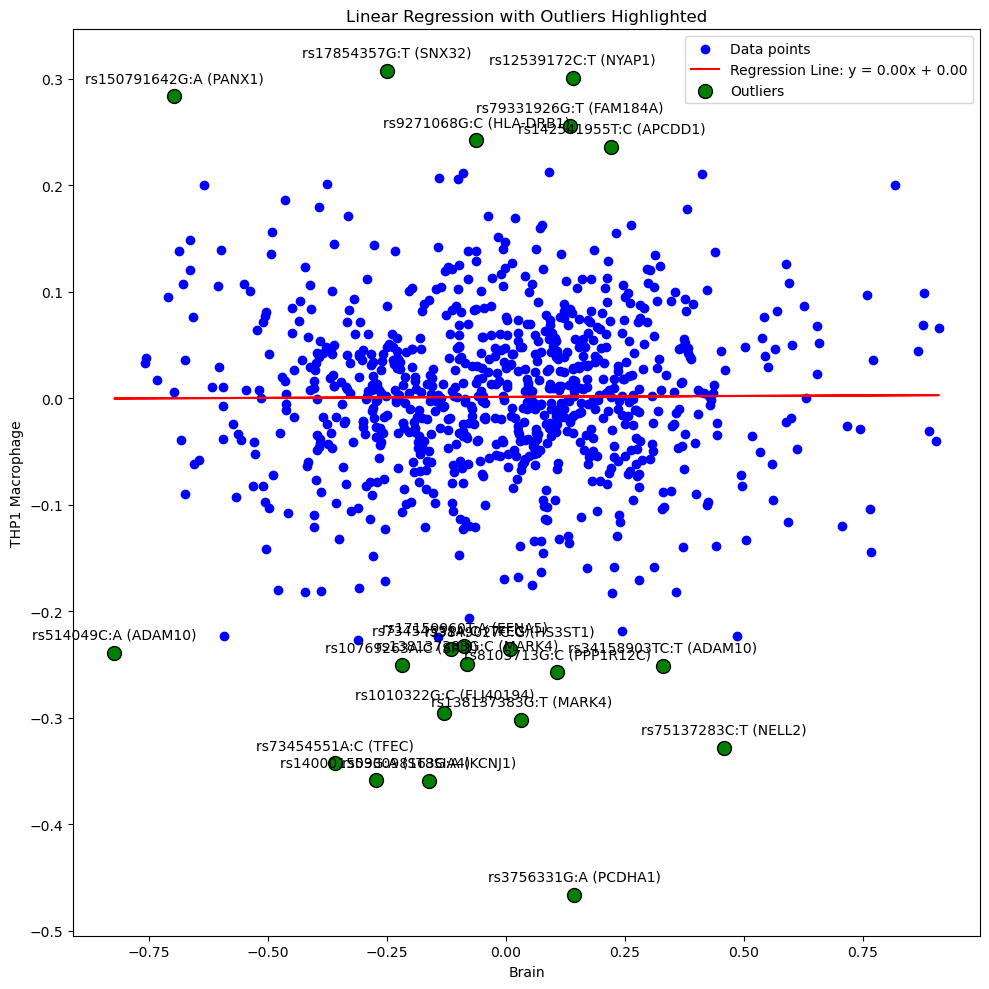

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
x_name = 'Brain'
y_name = 'THP1 Macrophage'
# Assuming you have loaded your DataFrame 'final_df' and it contains the 'THP1_LPSIFNG' and 'THP1_Naive' columns
x = final_df[x_name]
y = final_df[y_name]

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Regression line: y = {slope:.2f}x + {intercept:.2f}")

# Calculate predicted values
y_pred = slope * x + intercept

# Calculate residuals
residuals = y - y_pred

# Determine outlier threshold (e.g., 2 standard deviations)
threshold = 2.7 * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Regression Line: y = {slope:.2f}x + {intercept:.2f}')  # regression line

# Highlight outliers
plt.scatter(x[outliers], y[outliers], color='green', s=100, edgecolor='black', label='Outliers')

# Annotations for outliers
for idx in x[outliers].index:
    label = final_df.loc[idx, 'rsid_gene']
    plt.annotate(label, (x[idx], y[idx]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Linear Regression with Outliers Highlighted')
plt.xlabel(x_name)
plt.ylabel(y_name)
#plt.xlim(-1.5,1.5)
#plt.ylim(-1.5,1.5)
plt.legend()
plt.tight_layout()
plt.show()


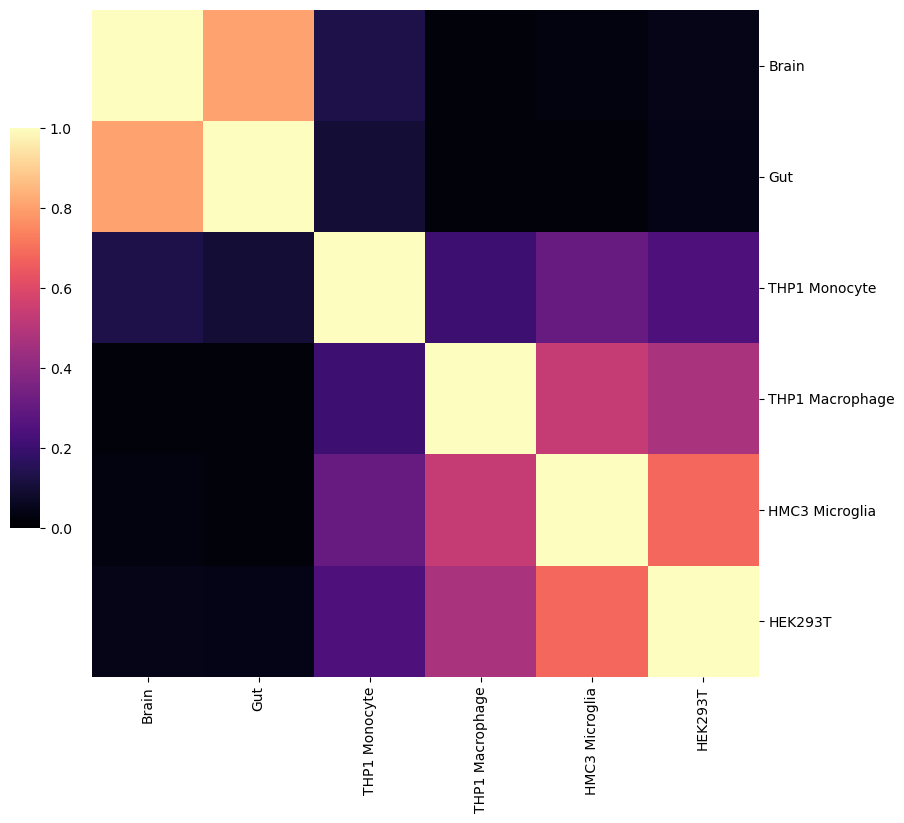

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
cg = sns.clustermap(final_df[['THP1 Monocyte','THP1 Macrophage','Brain','HMC3 Microglia','Gut',"HEK293T"]].corr('spearman'),vmin=0,annot=False,fmt=".2f", cmap='magma')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_position([0.1, 0.3, 0.03, 0.4])  

plt.savefig('allele_differences_logFC_correlation_by_tissue_Heatmap.pdf', format='pdf')

<Figure size 4500x3600 with 0 Axes>

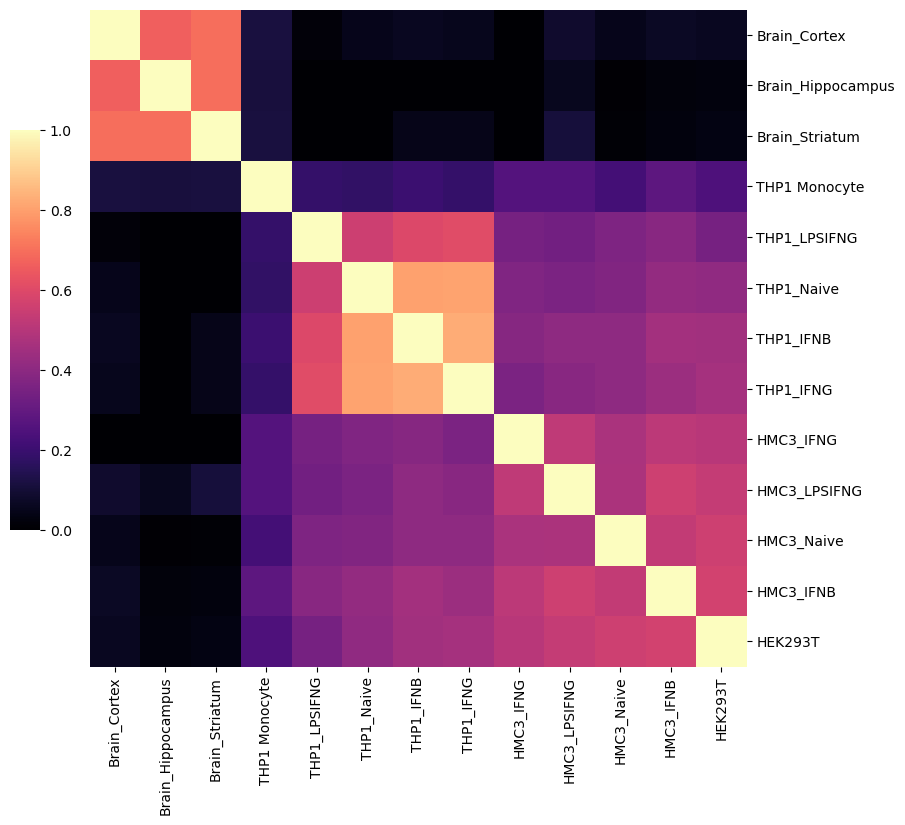

In [43]:
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 12), dpi=300)
cg = sns.clustermap(final_df.drop(['THP1 Macrophage','Brain','HMC3 Microglia','Gut','HMC3THP1mac_CommonEffects','Large_Intestine','Small_Intestine'],axis=1).corr('spearman'),vmin=0,annot=False,fmt=".2f", cmap='magma')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_position([0.1, 0.3, 0.03, 0.4])  
plt.savefig('allele_differences_logFC_correlation_by_celltype_Heatmap.pdf', format='pdf')

In [55]:
lookup_table_diff = final_df
df_haploreg = pd.read_csv('indexing/SNP_haploreg_annotated_20231204.csv' ,index_col=0)
lookup_table_diff = pd.merge(lookup_table_diff,df_haploreg,right_index=True,left_index=True)
df_haploreg = pd.read_csv('indexing/variants_peak_annotation_bulkATAC_20240109.csv' ,index_col=0)
lookup_table_diff = pd.merge(lookup_table_diff,df_haploreg,right_index=True,left_index=True)

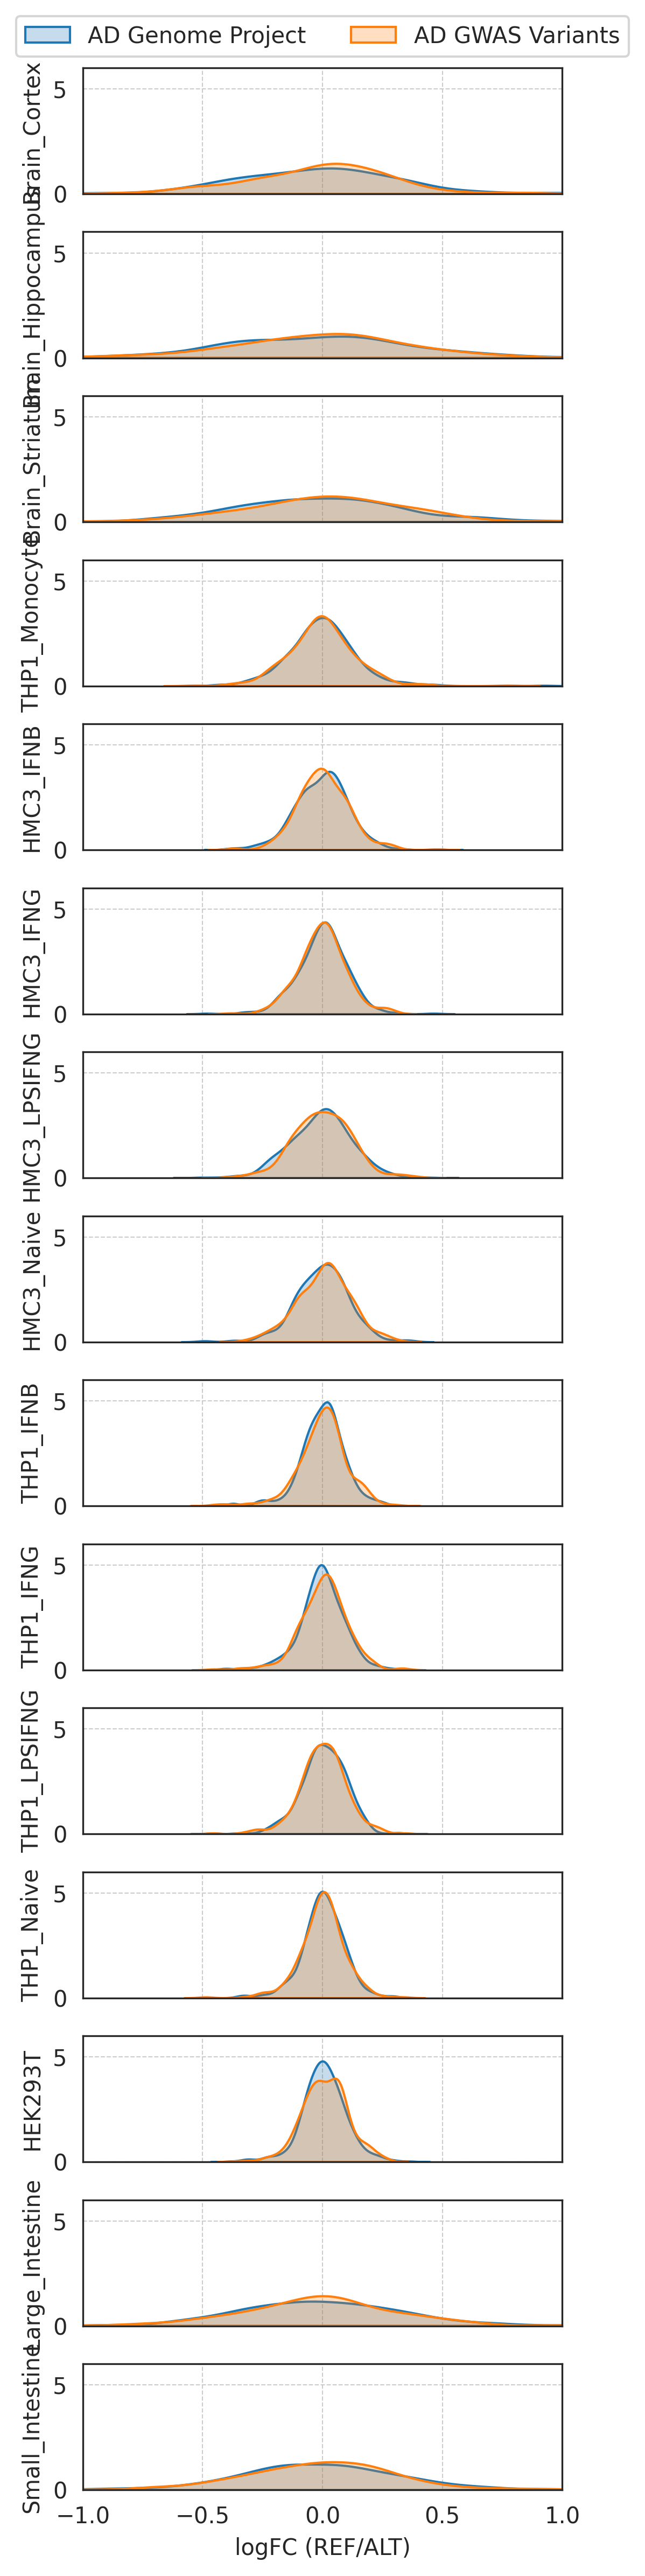

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl

plt.rcParams['figure.dpi'] = 300 
sns.set_style("white", {'axes.grid': True, 'grid.linestyle': '--'})
mpl.rcParams['grid.linewidth'] = 0.5 

# Assuming 'lookup_table_diff' is your DataFrame and it has a column named 'Contributor_x'
# Filtering the DataFrame based on 'Contributor_x'
group1 = lookup_table_diff[lookup_table_diff['Contributor_x'].isin(['Tanzi', 'Hide'])]
group2 = lookup_table_diff[lookup_table_diff['Contributor_x'].isin(['Pfenning', 'Kellis'])]

# Create a figure
fig, axes = plt.subplots(15, 1, figsize=(4, 16), sharex=True)

# Loop over the columns and plot KDE for each group
for i, col in enumerate(['Brain_Cortex', 'Brain_Hippocampus', 'Brain_Striatum', 'THP1_Monocyte',
       'HMC3_IFNB', 'HMC3_IFNG', 'HMC3_LPSIFNG', 'HMC3_Naive', 'THP1_IFNB',
       'THP1_IFNG', 'THP1_LPSIFNG', 'THP1_Naive', 'HEK293T','Large_Intestine',"Small_Intestine"]):
    sns.kdeplot(group1[col], ax=axes[i], fill=True, label='AD Genome Project')
    sns.kdeplot(group2[col], ax=axes[i], fill=True, label='AD GWAS Variants')
    axes[i].set_ylabel(col)
    axes[i].set_xlim(-1, 1)
    axes[i].set_ylim([0, 6])

# Set legend on the top of the figure
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.5), ncol=2)

plt.xlabel("logFC (REF/ALT)")
plt.tight_layout()
plt.savefig('MPRA_logFC.png', dpi=300)
plt.show()


/home/zihengc/anaconda3/envs/bio/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


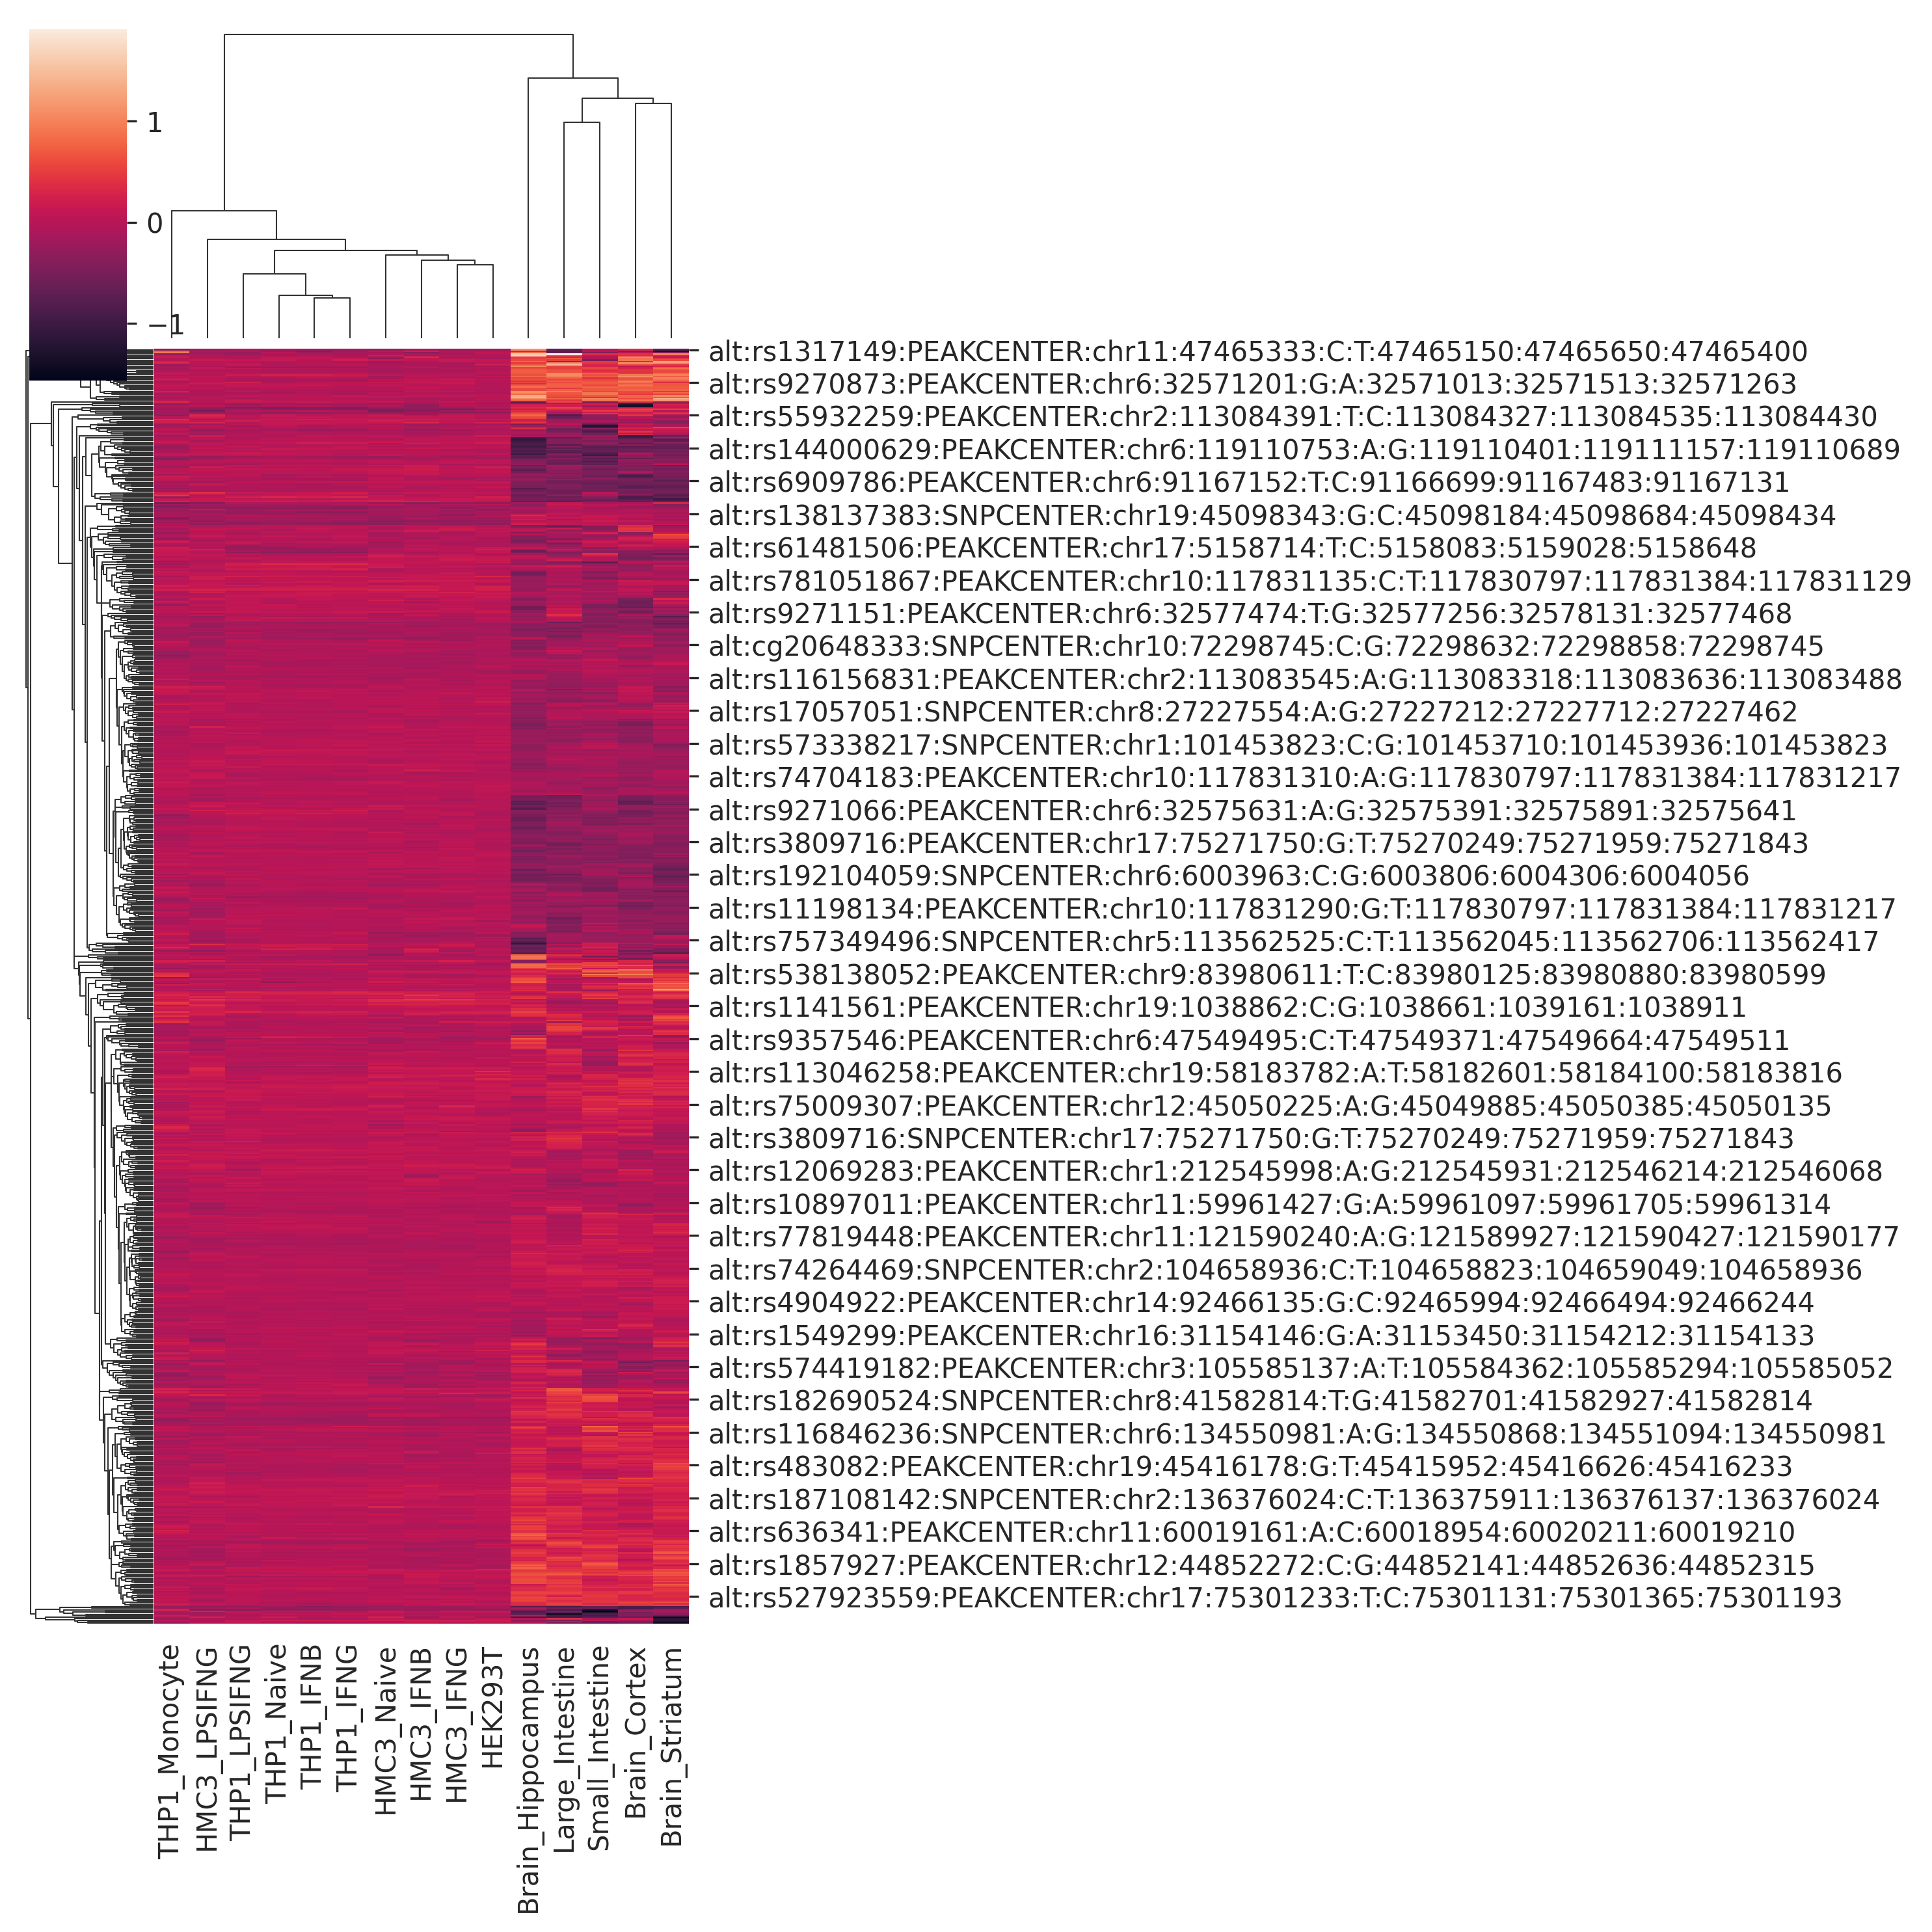

In [58]:
sns.clustermap(final_df.iloc[~final_df.index.str.contains("motifdisrupt")])

In [59]:
import pandas as pd
import os
import pandas as pd

# Directory containing the folders
base_dir = 'allele_differences/Brain_HEK293T_for_plotting'
# Initialize an empty DataFrame for the final result
final_df = pd.DataFrame()

# Loop through each folder in the base directory
for file in os.listdir(base_dir):
        file_path = os.path.join(base_dir, file)

        df_ref = pd.read_csv(file_path,index_col=0)[["logFC"]]
        df_ref.columns = [file[21:-11]]

        # Append to the final DataFrame
        final_df = pd.concat([final_df, df_ref],axis=1)

df_snponly = final_df.iloc[31:][~final_df.iloc[31:].index.str.contains("motifdisrupt")]

df_index = pd.read_csv('indexing/variants_peak_annotation_bulkATAC_20240109.csv',index_col=0)
df_index2 = pd.read_csv('indexing/index_20240103_curated.csv',index_col=0)["center"]
df = df_snponly 
df = pd.merge(df,df_index,left_index=True,right_index=True,how='left')
df = pd.merge(df,df_index2,left_index=True,right_index=True,how='left')

sns.clustermap(df_snponly.loc[list(set((df[df["HEK293T_DNase_ENCODE"]==1].index).append(df[df["fullard_hippocampus_putaman_merged"]==1].index)))],vmin=-1,vmax=1)

FileNotFoundError: [Errno 2] No such file or directory: 'allele_differences/Brain_HEK293T_for_plotting'

In [ ]:
#################need keep#############
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Input files
files = {
    "IFN-β": "annotated_20240616_comparative_THP1_IFNB_alleleOnly.csv",
    "IFN-γ": "annotated_20240616_comparative_THP1_IFNG_alleleOnly.csv",
    "LPS+IFN-γ": "annotated_20240616_comparative_THP1_LPSIFNG_alleleOnly.csv",
    "Naive": "annotated_20240616_comparative_THP1_Naive_alleleOnly.csv",
}

value_col = "logFC_converted"

# Load allele-effect values and align by shared variant/element IDs
series = {}
for label, path in files.items():
    df = pd.read_csv(path, index_col=0)

    s = pd.to_numeric(df[value_col], errors="coerce")
    s = s[~s.index.duplicated(keep="first")]

    series[label] = s

mat = pd.concat(series, axis=1, join="inner").dropna()

# Pearson correlation
corr = mat.corr(method="pearson")

# Save correlation matrix
corr.to_csv("THP1_cross_condition_allelic_effect_correlation_matrix_greek.csv")

# Plot
fig, ax = plt.subplots(figsize=(5.3, 4.55), dpi=300)

im = ax.imshow(
    corr.values,
    vmin=0,
    vmax=1,
    cmap="Blues",
    aspect="equal"
)

labels = list(corr.columns)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(
    labels,
    fontsize=16,
    rotation=35,
    ha="right",
    rotation_mode="anchor"
)
ax.set_yticklabels(labels, fontsize=16)

# Cell gridlines
ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.6)

ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

# Cell annotations
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if val >= 0.78 else "black"
        )

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "THP-1 allelic-effect correlation",
    fontsize=18,
    pad=12
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.042, pad=0.035)
cbar.set_label("Pearson r", fontsize=15)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()

plt.savefig(
    "THP1_cross_condition_allelic_effect_correlation_heatmap_greek.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()